# Travel Destination Recommendation — Data Preprocessing

**Objective:** Prepare the dataset for predicting `DestinationName` using supervised multi-class classification.


## Data Preprocessing

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

# Load raw data
df_users = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Final_Updated_Expanded_Users.csv')
df_history = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Final_Updated_Expanded_UserHistory.csv')
df_destinations = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Expanded_Destinations.csv')
df_reviews = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Final_Updated_Expanded_Reviews.csv')

print('Datasets loaded successfully')

Datasets loaded successfully


---
## 1. Data Quality Assessment

In [22]:
df_destinations.rename(columns={'Name': 'DestinationName'}, inplace=True)
df = pd.merge(pd.merge(pd.merge(df_history, df_users, on='UserID'), df_destinations, on='DestinationID'), df_reviews, on=['UserID', 'DestinationID'], how='left')

print('Datasets merged successfully.')


print('\n' + '=' * 60)
print('MERGED DATASET (Users + History + Destinations + Reviews)')
print('=' * 60)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.describe(include='all'))
print('\nMissing Values (merged):\n', df.isnull().sum())
print('\nFirst 10 rows of merged dataset:')
display(df.head(10))

Datasets merged successfully.

MERGED DATASET (Users + History + Destinations + Reviews)
Shape: (1510, 21)
Columns: ['HistoryID', 'UserID', 'DestinationID', 'VisitDate', 'ExperienceRating', 'Name', 'Email', 'Preferences', 'Gender', 'NumberOfAdults', 'NumberOfChildren', 'Age', 'Budget', 'DestinationName', 'State', 'Type', 'Popularity', 'BestTimeToVisit', 'ReviewID', 'Rating', 'ReviewText']


,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating,Name,Email,Preferences,Gender,NumberOfAdults,...,Age,Budget,DestinationName,State,Type,Popularity,BestTimeToVisit,ReviewID,Rating,ReviewText
count,1510.000000,1510.000000,1510.000000,1510,1510.000000,1510,1510,1510,1510,1510.000000,...,1510.000000,1510,1510,1510,1510,1510.000000,1510,0.0,0.0,0
unique,NaN,NaN,NaN,603,NaN,20,20,5,2,NaN,...,NaN,3,25,17,16,NaN,5,NaN,NaN,0
top,NaN,NaN,NaN,2023-10-02,NaN,Aanya,aanya@example.com,Nature & Adventure,Male,NaN,...,NaN,Medium,Munnar,Kerala,Historical City,NaN,Apr-Jun,NaN,NaN,NaN
freq,NaN,NaN,NaN,10,NaN,92,92,326,762,NaN,...,NaN,637,110,200,283,NaN,398,NaN,NaN,NaN
mean,755.500000,499.353642,12.993377,NaN,4.141722,NaN,NaN,NaN,NaN,1.504636,...,34.935762,NaN,NaN,NaN,NaN,8.438000,NaN,NaN,NaN,NaN
std,436.043767,286.942601,7.053048,NaN,0.994908,NaN,NaN,NaN,NaN,0.500144,...,10.963545,NaN,NaN,NaN,NaN,0.593015,NaN,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,...,18.000000,NaN,NaN,NaN,NaN,7.560000,NaN,NaN,NaN,NaN
25%,378.250000,251.000000,7.000000,NaN,4.000000,NaN,NaN,NaN,NaN,1.000000,...,27.000000,NaN,NaN,NaN,NaN,7.900000,NaN,NaN,NaN,NaN
50%,755.500000,501.500000,13.000000,NaN,4.000000,NaN,NaN,NaN,NaN,2.000000,...,35.000000,NaN,NaN,NaN,NaN,8.650000,NaN,NaN,NaN,NaN
75%,1132.750000,741.000000,19.000000,NaN,5.000000,NaN,NaN,NaN,NaN,2.000000,...,42.000000,NaN,NaN,NaN,NaN,8.900000,NaN,NaN,NaN,NaN



Missing Values (merged):
 HistoryID              0
UserID                 0
DestinationID          0
VisitDate              0
ExperienceRating       0
Name                   0
Email                  0
Preferences            0
Gender                 0
NumberOfAdults         0
NumberOfChildren       0
Age                    0
Budget                 0
DestinationName        0
State                  0
Type                   0
Popularity             0
BestTimeToVisit        0
ReviewID            1510
Rating              1510
ReviewText          1510
dtype: int64

First 10 rows of merged dataset:


,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating,Name,Email,Preferences,Gender,NumberOfAdults,...,Age,Budget,DestinationName,State,Type,Popularity,BestTimeToVisit,ReviewID,Rating,ReviewText
0,1,1,4,2023-02-28,4,Kavya,kavya@example.com,Beaches & Relaxation,Female,1,...,40,Low,Pondicherry,Pondicherry,Coastal City,8.85,Apr-Jun,NaN,NaN,NaN
1,2,1,22,2024-05-15,3,Kavya,kavya@example.com,Beaches & Relaxation,Female,1,...,40,Low,Dharamshala,Himachal Pradesh,Mountain Monasteries,9.16,Apr-Jun,NaN,NaN,NaN
2,3,2,15,2024-06-07,4,Rohan,rohan@example.com,Nature & Adventure,Male,2,...,33,Low,Jim Corbett,Uttarakhand,National Park,9.41,Nov-Mar,NaN,NaN,NaN
3,4,2,12,2023-11-21,5,Rohan,rohan@example.com,Nature & Adventure,Male,2,...,33,Low,Rishikesh,Uttarakhand,Mountain/River,9.02,Nov-Feb,NaN,NaN,NaN
4,5,3,19,2023-03-18,4,Kavya,kavya@example.com,Cultural & Food,Female,2,...,42,Medium,Hyderabad,Telangana,Metropolis,8.96,Apr-Jun,NaN,NaN,NaN
5,6,3,18,2023-07-09,5,Kavya,kavya@example.com,Cultural & Food,Female,2,...,42,Medium,Lucknow,Uttar Pradesh,Historical City,8.71,Oct-Mar,NaN,NaN,NaN
6,7,4,17,2023-01-08,3,Anika,anika@example.com,Cultural & Food,Female,1,...,53,Medium,Amritsar,Punjab,Historical City,7.69,Nov-Mar,NaN,NaN,NaN
7,8,4,18,2023-07-09,4,Anika,anika@example.com,Cultural & Food,Female,1,...,53,Medium,Lucknow,Uttar Pradesh,Historical City,8.71,Oct-Mar,NaN,NaN,NaN
8,9,5,5,2024-10-23,4,Tanvi,tanvi@example.com,Beaches & Relaxation,Female,2,...,32,Low,Varkala,Kerala,Cliff Beach,7.67,Sep-Mar,NaN,NaN,NaN
9,10,6,6,2024-08-13,5,Karan,karan@example.com,City & Historical,Male,2,...,32,High,Jaipur,Rajasthan,Historical City,7.56,Oct-Mar,NaN,NaN,NaN


In [23]:
df['VisitDate'] = pd.to_datetime(df['VisitDate'])
df['TravelMonth'] = df['VisitDate'].dt.month
for p in ['Relaxation', 'Adventure', 'Culture', 'Spiritual']:
    df[f'Pref_{p}'] = df['Preferences'].apply(lambda x: 1 if p in str(x) else 0)

print('Basic feature engineering complete.')

Basic feature engineering complete.


## 2. Basic Feature Engineering

In [24]:
# Calculate average rating per destination
dest_ratings = df_reviews.groupby('DestinationID')['Rating'].agg(['mean', 'count']).reset_index()
dest_ratings.columns = ['DestinationID', 'Avg_Dest_Rating', 'Review_Count']

# Merge with main dataframe
df = pd.merge(df, dest_ratings, on='DestinationID', how='left')

# Fill missing values
df['Avg_Dest_Rating'] = df['Avg_Dest_Rating'].fillna(df['Avg_Dest_Rating'].mean())
df['Review_Count'] = df['Review_Count'].fillna(0)

# Enhanced feature engineering
df['VisitDate'] = pd.to_datetime(df['VisitDate'])
df['TravelMonth'] = df['VisitDate'].dt.month
df['TravelSeason'] = pd.cut(df['TravelMonth'], bins=[0, 3, 6, 9, 12], labels=['Winter', 'Spring', 'Summer', 'Fall'])

# User preference scores (how well destination matches user preferences)
preference_mapping = {
    'Relaxation': ['Beach', 'Coastal City', 'Hill Station'],
    'Adventure': ['Island', 'Hill Station', 'National Park'],
    'Culture': ['Historical', 'Temple', 'Fort'],
    'Spiritual': ['Temple', 'Ashram', 'Pilgrimage']
}

def calculate_preference_match(row):
    user_prefs = str(row['Preferences']).lower()
    dest_type = str(row['Type']).lower()
    score = 0
    for pref, types in preference_mapping.items():
        if pref.lower() in user_prefs:
            if any(t.lower() in dest_type for t in types):
                score += 1
    return score

df['Preference_Match_Score'] = df.apply(calculate_preference_match, axis=1)

# Age group categorization
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['Young', 'Adult', 'Middle', 'Senior', 'Elder'])

# Family size
df['Family_Size'] = df['NumberOfAdults'] + df['NumberOfChildren']
df['Has_Children'] = (df['NumberOfChildren'] > 0).astype(int)

# Budget compatibility score
budget_scores = {'Low': 1, 'Medium': 2, 'High': 3}
df['Budget_Score'] = df['Budget'].map(budget_scores)

# Seasonal popularity match
seasonal_destinations = {
    'Winter': ['Hill Station', 'Temple'],
    'Spring': ['Beach', 'Coastal City'],
    'Summer': ['Hill Station', 'Island'],
    'Fall': ['Historical', 'Temple']
}

def seasonal_match(row):
    season = row['TravelSeason']
    dest_type = str(row['Type'])
    if season in seasonal_destinations:
        return 1 if dest_type in seasonal_destinations[season] else 0
    return 0

df['Seasonal_Match'] = df.apply(seasonal_match, axis=1)

print('Enhanced feature engineering complete.')
print(f'New features added: {["Avg_Dest_Rating", "Review_Count", "TravelSeason", "Preference_Match_Score", "Age_Group", "Family_Size", "Has_Children", "Budget_Score", "Seasonal_Match"]}')

Enhanced feature engineering complete.
New features added: ['Avg_Dest_Rating', 'Review_Count', 'TravelSeason', 'Preference_Match_Score', 'Age_Group', 'Family_Size', 'Has_Children', 'Budget_Score', 'Seasonal_Match']


---
## 3. Data Preparation

In [25]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

df_clean = df[df['ExperienceRating'] >= 4].copy()
le_dest = LabelEncoder()
df_clean['Target_Destination'] = le_dest.fit_transform(df_clean['DestinationName'])

# Enhanced feature lists
numeric_features = ['Age', 'NumberOfAdults', 'NumberOfChildren', 'TravelMonth', 'Avg_Dest_Rating', 'Review_Count', 'Preference_Match_Score', 'Family_Size', 'Budget_Score']
categorical_features = ['Gender', 'Budget', 'Pref_Relaxation', 'Pref_Adventure', 'Pref_Culture', 'Pref_Spiritual', 'TravelSeason', 'Age_Group', 'Has_Children', 'Seasonal_Match']

X = df_clean[numeric_features + categorical_features]
y = df_clean['Target_Destination']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Enhanced preprocessing with StandardScaler and feature selection
preprocessor_enhanced = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

preprocessor = preprocessor_enhanced  # For initial models

preprocessor_unscaled = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Alternative: Polynomial features for LR
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
preprocessor_poly = ColumnTransformer([
    ('num_poly', Pipeline([('scaler', StandardScaler()), ('poly', poly)]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Feature selection
preprocessor_selected = Pipeline([
    ('preprocessing', preprocessor_enhanced),
    ('feature_selection', SelectKBest(score_func=f_classif, k=50))  # Select top 50 features
])

class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

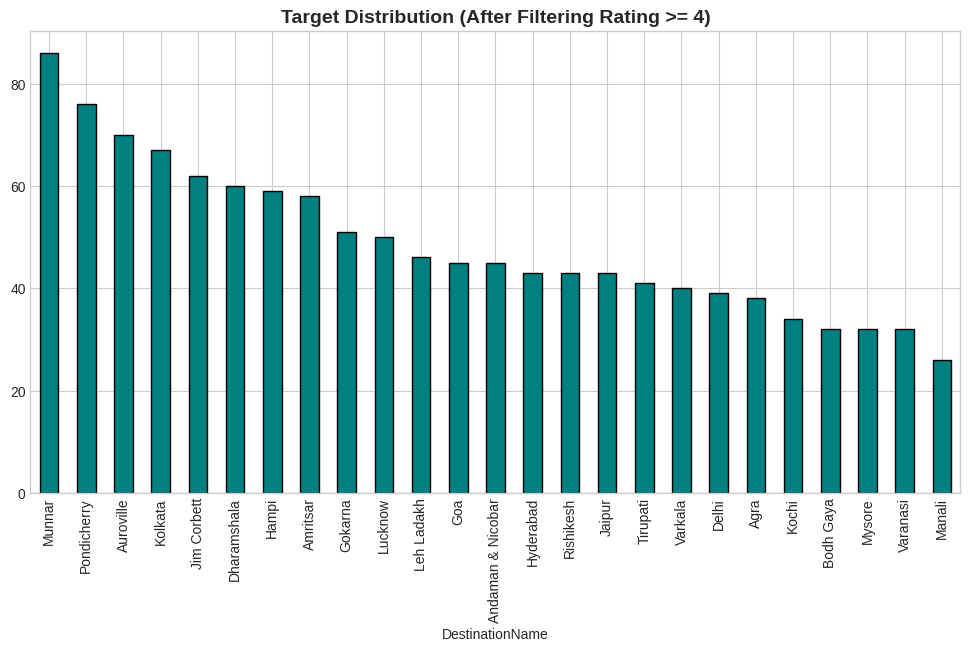

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
df_clean['DestinationName'].value_counts().plot(kind='bar', ax=ax, color='teal', edgecolor='black')
ax.set_title('Target Distribution (After Filtering Rating >= 4)', fontsize=14, fontweight='bold')
plt.show()
results_dict = {}

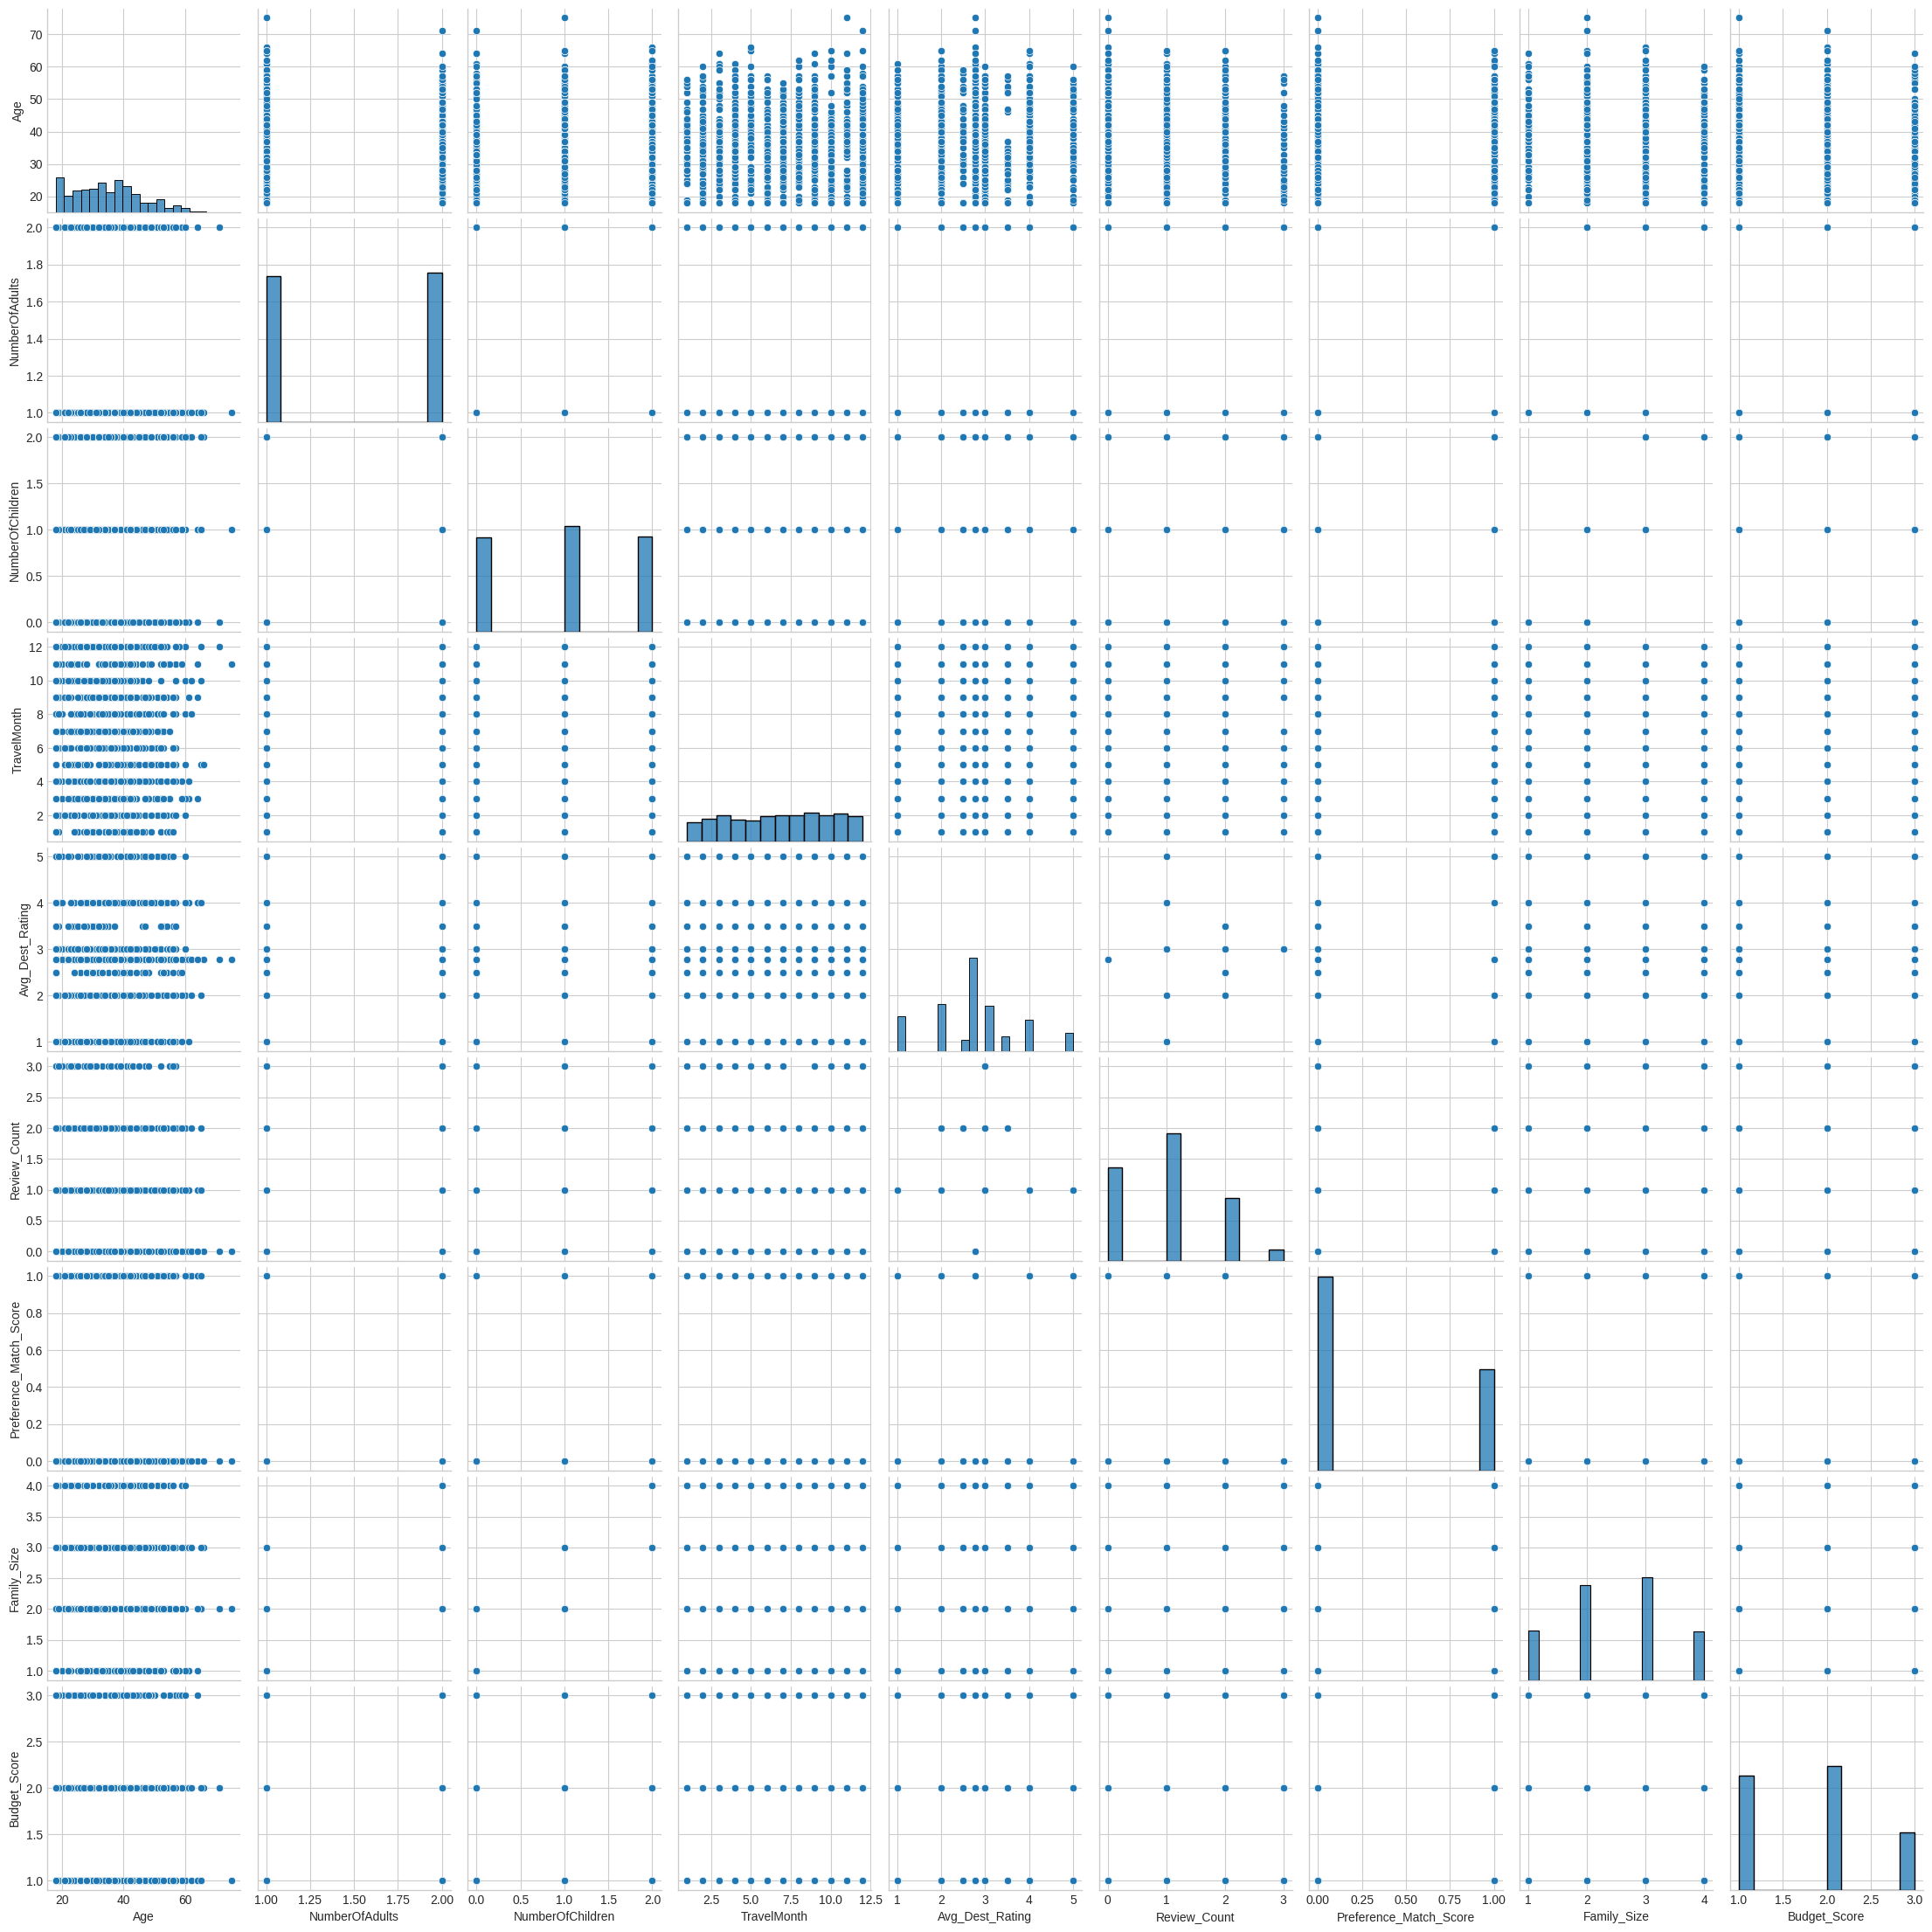

In [27]:
# Pairplot for numeric features
sns.pairplot(df_clean[numeric_features])
plt.show()

In [28]:
import os

# Create processed directory if it doesn't exist
os.makedirs("../dataset/processed", exist_ok=True)

# Export the processed dataframe
df_clean.to_csv("../dataset/processed/processed_travel_data.csv", index=False)

print("Processed data exported to ../dataset/processed/processed_travel_data.csv")

Processed data exported to ../dataset/processed/processed_travel_data.csv
